# train

## import

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForaging as AF
from auditoryforage.AF_env import AuditoryForagingReward as AFR
from stable_baselines3 import PPO
from multiprocessing import Pool
import multiprocessing as mp
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict
import seaborn as sns

## train

In [5]:
food_reward_list = [1000, 1100, 1200, 1300, 1400]
att_coeff = 0.087213 #0.087213
att_temp = 0.25 # 0.25
penalty_cost = -30 #  -30
time_in_game_reward = 0. # old 0
# num_epochs = 11
# seed_value = 1

## food reward as a paramter input

In [40]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForaging as AF
from auditoryforage.AF_env import AuditoryForagingReward as AFR
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel


food_reward_list = [1000, 1100, 1200, 1300, 1400, 1500]
att_coeff = 0.087213
att_temp = 0.25
penalty_cost = -30
time_in_game_reward = 0.
num_epochs = 44
seed_value = 1

# for food_reward in food_reward_list:
#     task=AF()
#     task.food_reward=food_reward
#     model = PPO('MlpPolicy', task, verbose=1)
#     model.learn(total_timesteps=100)

task=AFR()
task.food_reward=1500
task.food_reward_list=food_reward_list
task.attention_cost_coeff=att_coeff
task.attention_cost_temp=att_temp
task.penalty_cost=penalty_cost
task.time_in_game_reward=time_in_game_reward
task.food_reward_list=food_reward_list
taskbelief=FuncBeliefModel(env=task, rng=1)
model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu')

/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


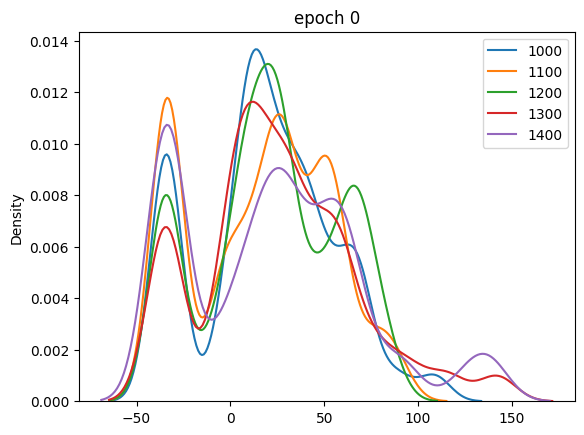

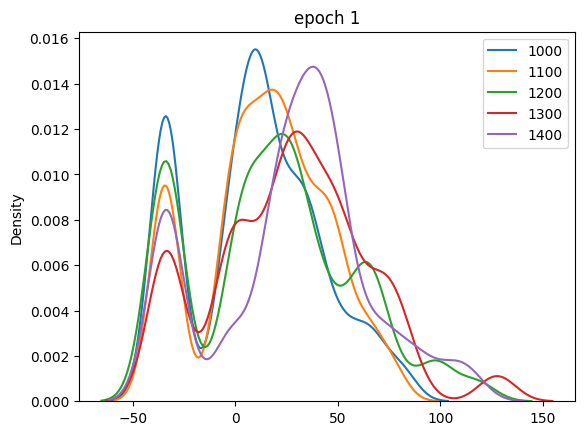

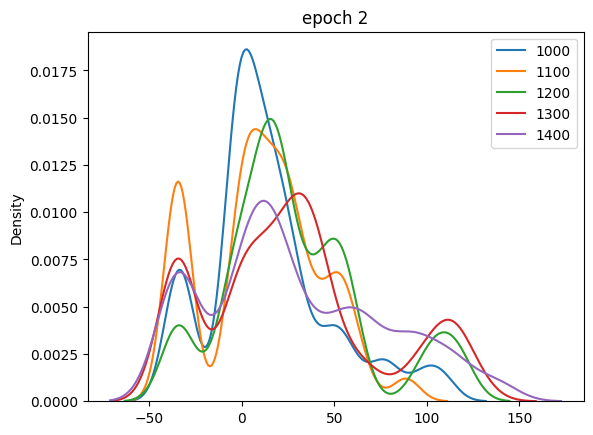

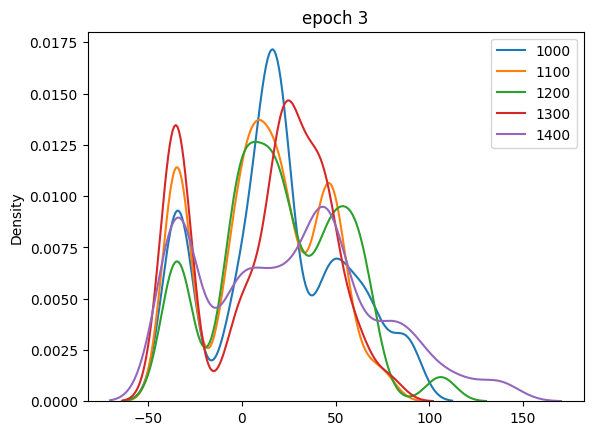

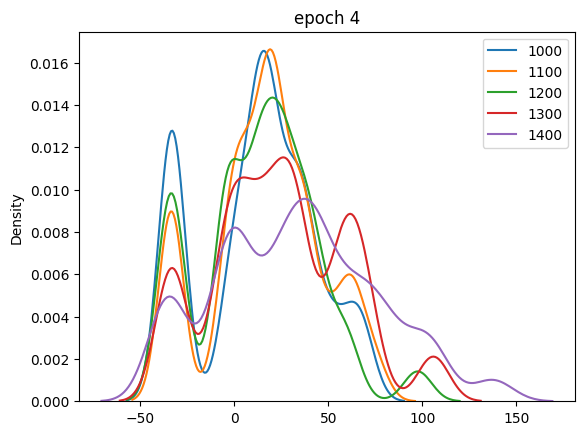

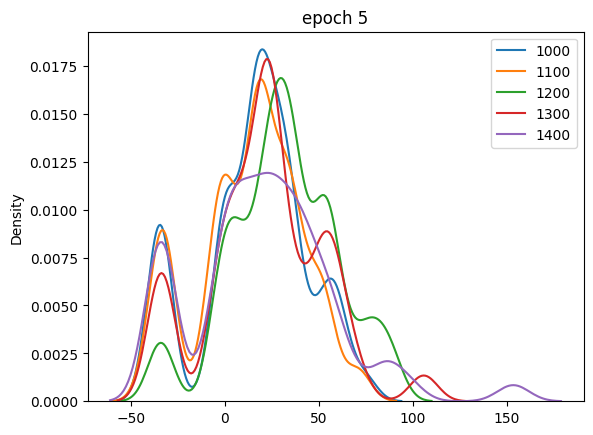

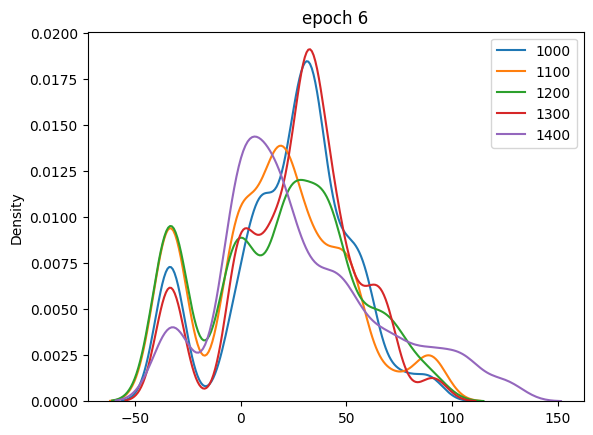

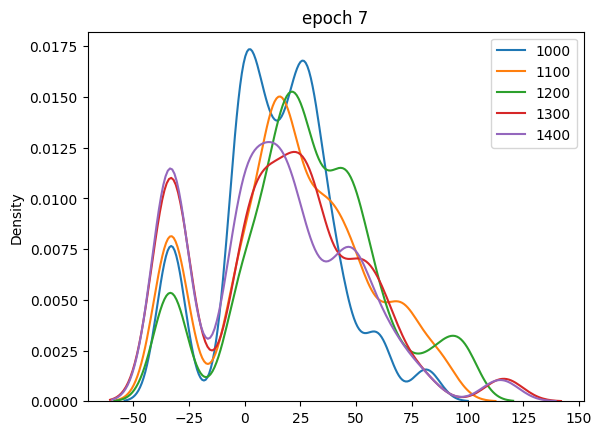

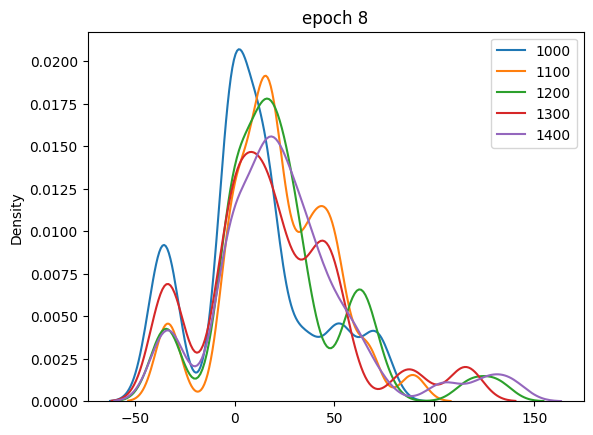

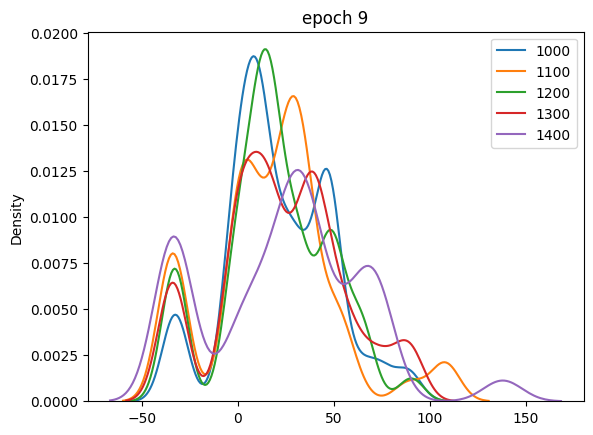

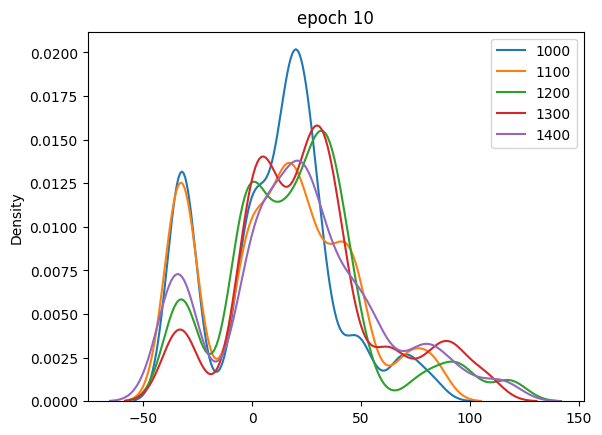

In [58]:
# train
for i in range(11):
    model.learn(total_timesteps=2222)

    # eval
    history_r=defaultdict(list)
    for _ in range(222):
        t=0
        total_r=0
        x=taskbelief.reset()  
        done=False
        while not done: 
            # model.predict(x)
            a,_=model.predict(x,deterministic=True)
            x, r, done, _ = taskbelief.step(a)
            # print(x, r,task.food_reward)
            t+=1
            total_r+=r
        # print(total_r)
        history_r[taskbelief.env.food_reward].append(total_r)
    for k in sorted(history_r.keys()):
        v=history_r[k]
        # _=plt.hist(v, bins=22, label=k, alpha=0.3, density=True)
        sns.kdeplot(v, fill=False, label=k,bw_adjust=0.5)
    plt.legend()
    plt.title(f'epoch {i}')
    plt.show()

## confirm the wrapper working for old env

In [38]:


food_reward_list = [1000, 1100, 1200, 1300, 1400, 1500]
att_coeff = 0.087213
att_temp = 0.25
penalty_cost = -30
time_in_game_reward = 0.
num_epochs = 44
seed_value = 1

# for food_reward in food_reward_list:
#     task=AF()
#     task.food_reward=food_reward
#     model = PPO('MlpPolicy', task, verbose=1)
#     model.learn(total_timesteps=100)

task=AF()
task.food_reward=1500
task.attention_cost_coeff=att_coeff
task.attention_cost_temp=att_temp
task.penalty_cost=penalty_cost
task.time_in_game_reward=time_in_game_reward
task.food_reward_list=food_reward_list
taskbelief=FuncBeliefModel(env=task, rng=1)
model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu')

/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


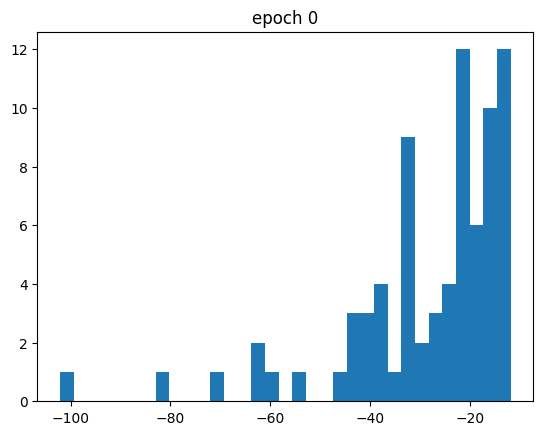

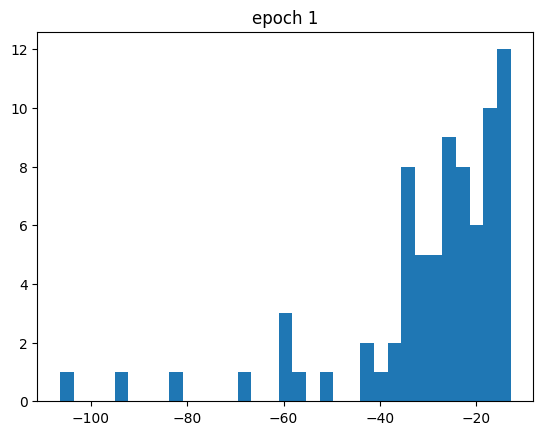

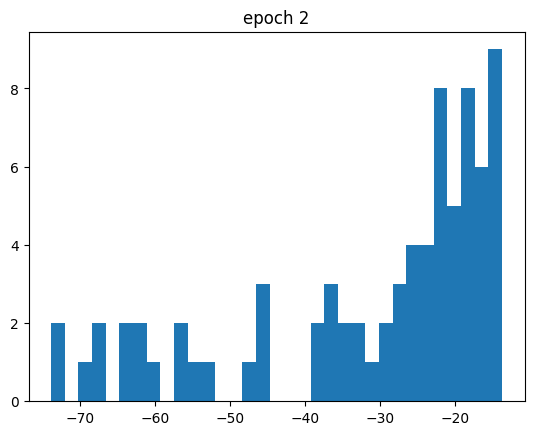

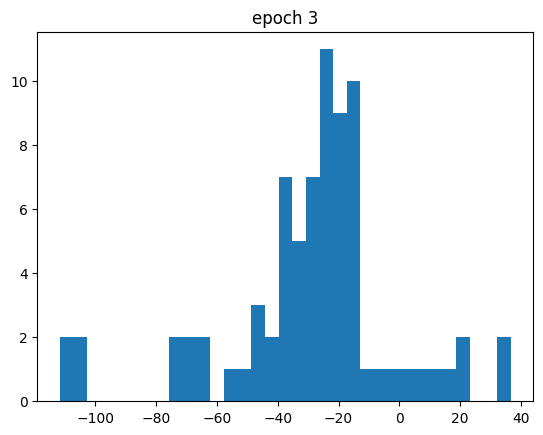

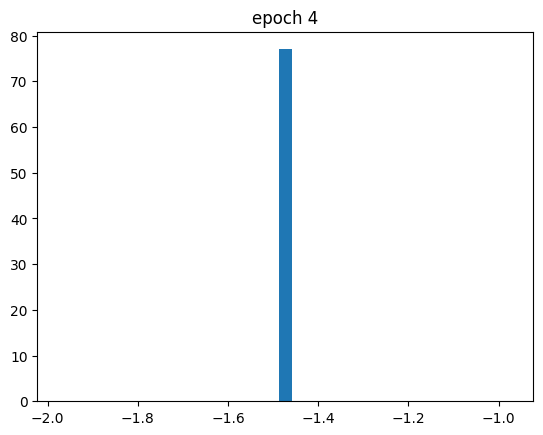

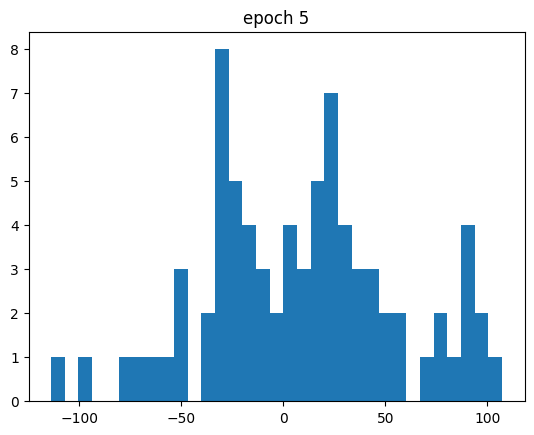

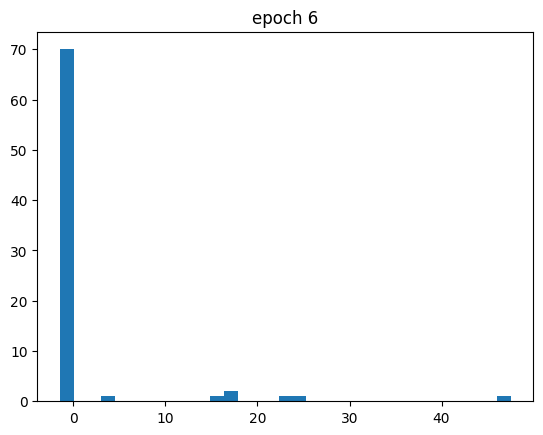

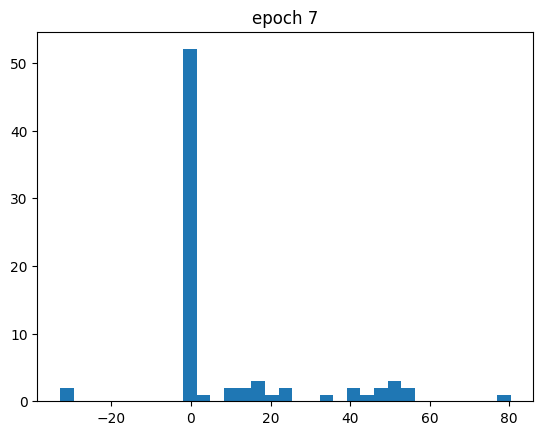

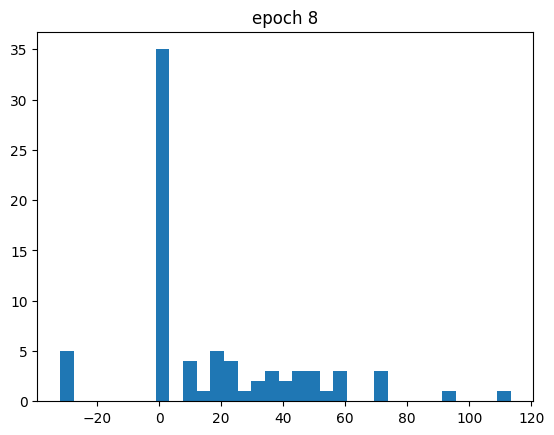

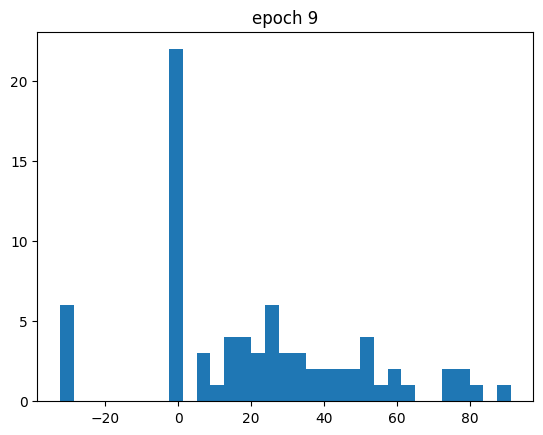

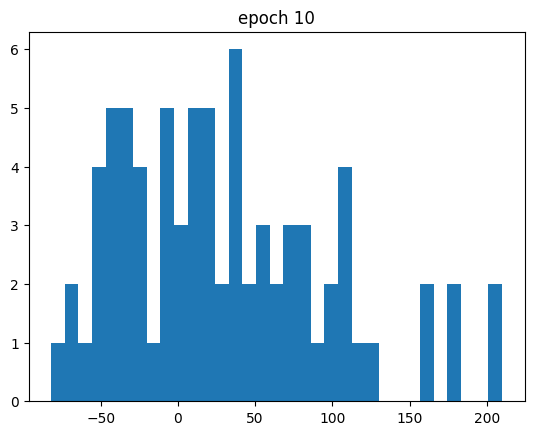

In [39]:
# train
for i in range(11):
    model.learn(total_timesteps=2222)

    # eval
    history_r=[]
    for _ in range(77):
        t=0
        total_r=0
        x=taskbelief.reset()  
        done=False
        while not done: 
            # model.predict(x)
            a,_=model.predict(x,deterministic=True)
            x, r, done, _ = taskbelief.step(a)
            # print(x, r,task.food_reward)
            t+=1
            total_r+=r
        # print(total_r)
        history_r.append(total_r)

    _=plt.hist(history_r, bins=33)
    # history_r 
        # print(task.food_reward)
    plt.title(f'epoch {i}')
    plt.show()